In [3]:
import numpy as np

class FeedForwardNN:
    def __init__(self, layer_sizes, hidden_activation='relu', output_activation='sigmoid', loss_type='bce', learning_rate=0.01):
        self.layer_sizes = layer_sizes
        self.hidden_act = hidden_activation
        self.output_act = output_activation
        self.loss_type = loss_type
        self.learning_rate = learning_rate
        self.L = len(layer_sizes) - 1

        self.weights = []
        self.biases = []
        self.pre_activations = []
        self.activations = []

        self.initialize_parameters()

    def initialize_parameters(self):
        np.random.seed(42)
        for i in range(self.L):
            W = np.random.randn(self.layer_sizes[i], self.layer_sizes[i+1]) * np.sqrt(2.0 / self.layer_sizes[i])
            b = np.zeros((1, self.layer_sizes[i+1]))
            self.weights.append(W)
            self.biases.append(b)

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        z_clipped = np.clip(z, -250, 250)
        return 1.0 / (1.0 + np.exp(-z_clipped))

    def sigmoid_derivative(self, z):
        s = self.sigmoid(z)
        return s * (1.0 - s)

    def activate(self, z, activation_type):
        if activation_type == 'relu': return self.relu(z)
        elif activation_type == 'sigmoid': return self.sigmoid(z)
        elif activation_type == 'linear': return z
        else: raise ValueError("Unsupported activation")

    def forward_propagation(self, X):
        self.activations = [X]
        self.pre_activations = []
        A = X

        for i in range(self.L - 1):
            Z = np.dot(A, self.weights[i]) + self.biases[i]
            self.pre_activations.append(Z)
            A = self.activate(Z, self.hidden_act)
            self.activations.append(A)

        Z_out = np.dot(A, self.weights[-1]) + self.biases[-1]
        self.pre_activations.append(Z_out)
        A_out = self.activate(Z_out, self.output_act)
        self.activations.append(A_out)

        return A_out

    def compute_loss(self, output, y):
        if self.loss_type == 'bce':
            epsilon = 1e-15
            output = np.clip(output, epsilon, 1 - epsilon)
            loss = -np.mean(y * np.log(output) + (1 - y) * np.log(1 - output))
        elif self.loss_type == 'mse':
            loss = np.mean((output - y) ** 2)
        return loss

    def backward_propagation(self, y):
        m = y.shape[0]
        grad_weights = [np.zeros_like(w) for w in self.weights]
        grad_biases  = [np.zeros_like(b) for b in self.biases]

        A_out = self.activations[-1]

        if self.loss_type == 'bce' and self.output_act == 'sigmoid':
            dZ = (A_out - y) / m
        elif self.loss_type == 'mse' and self.output_act == 'linear':
            dZ = 2 * (A_out - y) / m
        else:
            raise ValueError("Unsupported loss/activation pairing")

        for i in reversed(range(self.L)):
            A_prev = self.activations[i]

            grad_weights[i] = np.dot(A_prev.T, dZ)
            grad_biases[i] = np.sum(dZ, axis=0, keepdims=True)

            if i > 0:
                dA_prev = np.dot(dZ, self.weights[i].T)
                Z_prev = self.pre_activations[i-1]

                if self.hidden_act == 'relu':
                    dZ = dA_prev * self.relu_derivative(Z_prev)
                elif self.hidden_act == 'sigmoid':
                    dZ = dA_prev * self.sigmoid_derivative(Z_prev)

        return grad_weights, grad_biases

    def update_parameters(self, grad_weights, grad_biases):
        for i in range(self.L):
            self.weights[i] -= self.learning_rate * grad_weights[i]
            self.biases[i] -= self.learning_rate * grad_biases[i]

    def train(self, X, y, epochs=10000, print_freq=1000):
        for epoch in range(epochs):
            output = self.forward_propagation(X)
            loss = self.compute_loss(output, y)

            gw, gb = self.backward_propagation(y)
            self.update_parameters(gw, gb)

            if epoch % print_freq == 0:
                print(f"Epoch {epoch} | Loss: {loss:.6f}")

    def predict(self, X, threshold=0.5):
        output = self.forward_propagation(X)
        if self.output_act == 'sigmoid':
            return (output >= threshold).astype(int)
        return output

TASK 1: BINARY CLASSIFICATION (Two Moons)

Epoch 0 | Loss: 0.658108
Epoch 1000 | Loss: 0.035865
Epoch 2000 | Loss: 0.015445
Epoch 3000 | Loss: 0.010862
Epoch 4000 | Loss: 0.008780

Final Classification Accuracy: 100.00%


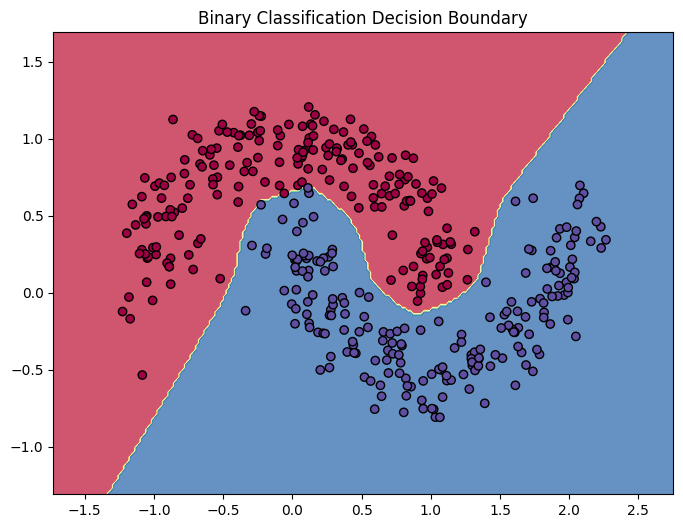


TASK 2: DEEP NEURAL NETWORK REGRESSION

Epoch 0 | Loss: 5.607979
Epoch 3000 | Loss: 0.024117
Epoch 6000 | Loss: 0.022045
Epoch 9000 | Loss: 0.021595
Epoch 12000 | Loss: 0.022209

Final Regression Mean Squared Error: 0.0219


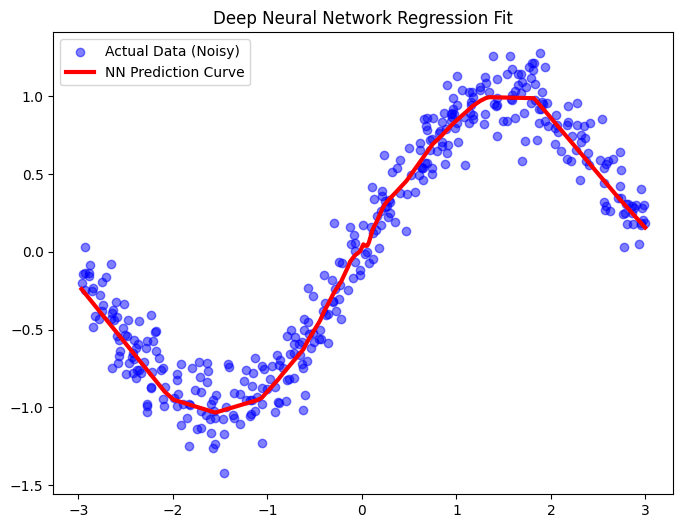

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def run_binary_classification():
    print("=========================================")
    print("TASK 1: BINARY CLASSIFICATION (Two Moons)")
    print("=========================================\n")

    try:
        data = np.genfromtxt('two_moons_data.csv', delimiter=',', skip_header=1)
        X = data[:, :2]
        Y = data[:, 2]
        Y = Y.reshape(-1, 1)
    except FileNotFoundError:
        print("Error: 'two_moons_data.csv' not found in the current directory.")
        return

    classifier = FeedForwardNN(
        layer_sizes=[2, 32, 32, 1],
        hidden_activation='relu',
        output_activation='sigmoid',
        loss_type='bce',
        learning_rate=0.1
    )

    classifier.train(X, Y, epochs=5000, print_freq=1000)

    predictions = classifier.predict(X)
    accuracy = np.mean(predictions == Y) * 100
    print(f"\nFinal Classification Accuracy: {accuracy:.2f}%")

    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
    Z = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Spectral)
    plt.scatter(X[:, 0], X[:, 1], c=Y.ravel(), cmap=plt.cm.Spectral, edgecolors='k')
    plt.title("Binary Classification Decision Boundary")
    plt.show()

def run_deep_regression():
    print("\n=========================================")
    print("TASK 2: DEEP NEURAL NETWORK REGRESSION")
    print("=========================================\n")

    X = np.random.uniform(-3, 3, (400,1))
    X = np.sort(X, axis=0)
    Y = np.sin(X) + np.random.randn(*X.shape) * 0.15

    regressor = FeedForwardNN(
        layer_sizes=[1, 32, 32, 32, 1],
        hidden_activation='relu',
        output_activation='linear',
        loss_type='mse',
        learning_rate=0.01
    )

    regressor.train(X, Y, epochs=15000, print_freq=3000)

    predictions = regressor.predict(X)
    mse = np.mean((predictions - Y)**2)
    print(f"\nFinal Regression Mean Squared Error: {mse:.4f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(X, Y, color='blue', alpha=0.5, label='Actual Data (Noisy)')
    plt.plot(X, predictions, color='red', linewidth=3, label='NN Prediction Curve')
    plt.title("Deep Neural Network Regression Fit")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_binary_classification()
    run_deep_regression()